# Section 1.2 — Evaluation of Resource Allocation

> **Basic.** Implement at least three simple metrics (e.g. average cycle time, average resource occupation, (weighted) resource fairness) and evaluate the allocation methods on the simulator. Describe the settings.
>
> **Advanced.** Design your own meaningful metrics, justify them, and re-evaluate.
>
> **Management question.** *"Fire two employees — which ones?"* How do you select them, and what is the impact on the metrics?

This notebook evaluates the allocation policies built in Part II (§1.8 seam, §1.1 k-Batching) on the simulator, and argues every metric and every management decision from measured numbers rather than intuition.

**Who counts as staff.** The deployed OrdinoR model supplies the active resource pool. The availability model marks `User_1` as automation, so resource-centric metrics and the management exercise use every *human in that active pool*; process-level metrics retain every case. This avoids silently evaluating a stale hardcoded subset.

**What we deliver**

| | Deliverable | Result |
|---|---|---|
| Basic | Average **cycle time**, average **resource occupation**, and **resource fairness** over the deployed human pool | Recomputed for each policy, seed, and common horizon |
| Advanced | **Time-to-first-offer**, **time-to-decision**, **handover rate**, and **rolling workload balance** | Adds customer-facing and within-horizon evidence to the aggregate metrics |
| Management | Context-aware criticality screening followed by a paired leave-2-out simulation | The selected staff and impact are generated from the current OrdinoR model, not fixed names or legacy permissions |

**The argument in one line.** Keep the runtime configuration explicit, evaluate the same deployed resource pool that the simulation uses, compare policies with paired replications, and price any staffing change with multiple outcome measures rather than one headline metric.

---

In [1]:
import sys
from pathlib import Path

# Works when Jupyter starts in either the repository root or notebooks/.
ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "analysis").is_dir() and (path / "simulation").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scripts.run_experiments as R
import scripts.opt_metrics as om
from analysis.availability import YearlyAvailability

# Match the house style of the 01/02 notebooks without the seaborn dependency.
BLUE, RED, GREY = "#4a6fa5", "#c0392b", "#7f8c8d"
plt.rcParams.update({
    "axes.grid": True, "grid.color": "#e2e2e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.edgecolor": "#bbbbbb",
    "figure.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

DAY = 86400.0
PERMISSION_MODE = "orgmodel"   # deployed Section 1.7 model
PROCESS_MODEL = "advanced"     # BPMN/Petri-net process model
BRANCHING_MODE = "visit"

# --- Human staff vs automation (reuse Johannes's Section 1.6 "Decision 4") ---
# Johannes showed one account breaches the structural weekday-coverage ceiling
# and has NO working calendar: it is an automated system account, not a person.
# We reuse that finding *data-drivenly* rather than hardcoding a name -- a
# simulated resource with no weekly working window in the §1.6 calendar is
# automation. Only human staff can be "fired" and only human load is a
# meaningful fairness/occupation signal, so the resource-centric metrics and
# the whole management question below are restricted to HUMANS. The automation
# still runs in the process, so cycle time / completions / customer milestones
# keep every case.
_CAL = YearlyAvailability.from_json(ROOT / "models" / "availability_model.json")
PERMS, _ = R.load_permission_model(PERMISSION_MODE, seed=42)
RESOURCE_POOL = set(PERMS.resources())
HUMANS = RESOURCE_POOL - _CAL.system
AUTOMATED = RESOURCE_POOL & _CAL.system
print(f"{len(RESOURCE_POOL)} simulated resources = "
      f"{len(HUMANS)} human staff + {len(AUTOMATED)} automated {sorted(AUTOMATED)}")
print(f"permission model: {PERMISSION_MODE}; process model: {PROCESS_MODEL}")

144 simulated resources = 143 human staff + 1 automated ['User_1']
permission model: orgmodel; process model: advanced


## 1. Experimental setup — the settings, stated once and reused everywhere

Every number below comes from the same runner (`scripts/run_experiments.run_once`), so the settings are stated once here and never silently vary between experiments.

- **Runtime configuration.** The BPMN/Petri-net process model, `visit` branching, and the deployed `orgmodel` permission model are passed explicitly to every run.
- **Horizon.** 21 simulated days from `2016-01-01`. Long enough that the resource calendar (§1.6) cycles through full working weeks; short enough that a full policy grid runs in seconds.
- **Replications.** Seeds `1..8`. Each seed is an independent arrival/branching/duration stream, so a policy's metric is a *mean over 8 runs* with a 95% CI, not a single lucky draw.
- **Common Random Numbers (CRN, §opt-B).** On. The same seed gives every policy the *same* case arrivals, branching, and durations — only the allocation order differs. This makes the comparison **paired**: a cycle-time gap between two policies at the same seed is caused by allocation alone, not by one policy happening to get an easier day.
- **Cycle time is measured on completed cases only.** Horizon-truncated cases (still running at day 21) have no end time; including them would bias cycle time downwards. `evaluate(..., completed_case_ids=...)` filters them.
- **Occupation is relative to the §1.6 availability windows**, not the raw log span — the slide-21 definition ("share the resources are working *during their availabilities*").

The policies under test:

| Policy | Deck | What it does |
|---|---|---|
| `random` | R-RMA (Russell Pattern 15) | Allocate a case to a uniformly random *permitted, free* resource. The §1.8 default baseline. |
| `piled` | R-PE (Piled Execution) | Prefer giving a resource another instance of the activity it just did — batch by activity. |
| `kbatch{1,5,10}` | k-Batching (Zeng & Zhao) | Hold arrivals into batches of `k` and solve an optimal assignment (`linear_sum_assignment`) per batch. `k=1` ≈ immediate allocation. |

In [2]:
SEEDS   = list(range(1, 9))
DAYS    = 21
POLICIES = ["random", "piled", "kbatch1", "kbatch5", "kbatch10"]

def run_policy(policy, seeds=SEEDS, days=DAYS, excluded=None, subset=None):
    # Run one policy across seeds; return list of full metric dicts (+ the df).
    # resource-centric metrics are restricted to `subset` (default: HUMANS);
    # for a leave-N-out run pass the SURVIVING humans so occupation/fairness
    # describe the people still employed, not the ones we just removed.
    subset = HUMANS if subset is None else subset
    out = []
    for s in seeds:
        df, meta = R.run_once(
            policy, s, days, "normal", True, PROCESS_MODEL, BRANCHING_MODE,
            permissions=PERMISSION_MODE, excluded_override=excluded,
        )
        if df.empty:
            continue
        m = om.evaluate(df, arrival_times=meta["arrival_times"],
                        availability_seconds=meta["availability_seconds"],
                        completed_case_ids=meta["completed_case_ids"],
                        resource_subset=subset)
        m["_seed"] = s
        m["_df"] = df
        out.append(m)
    return out

def ci95(x):
    x = np.asarray(x, float)
    if len(x) < 2:
        return 0.0
    # n=8 replications: use the two-sided Student-t critical value, not 1.96.
    return 2.365 * x.std(ddof=1) / np.sqrt(len(x))

print("Runner ready. Settings:",
      f"{len(POLICIES)} policies x {len(SEEDS)} seeds x {DAYS} days = "
      f"{len(POLICIES)*len(SEEDS)} simulations. Resource metrics over {len(HUMANS)} human staff.")

Runner ready. Settings: 5 policies x 8 seeds x 21 days = 40 simulations. Resource metrics over 143 human staff.


## 2. Basic — the three lecture metrics (deck 06, slide 21)

The three metrics are implemented once in `scripts/opt_metrics.py` and imported here — no re-derivation:

1. **`average_cycle_time`** — mean time to finish a process instance, measured **from case arrival** (not first activity start; the queue *before* the first activity is real delay the customer feels).
2. **`average_resource_occupation`** — mean busy-time to availability-window ratio for the deployed human pool. It is a comparative workload measure: because tasks may finish after a shift closes and capacity permits parallel work, it is not bounded by the nominal capacity.
3. **`resource_fairness`** — mean absolute deviation of per-resource occupation from the average. **0 = perfectly even load; lower is better.** The weighted variant down-weights resources that are barely ever available.

We run the full grid and aggregate.

In [3]:
results = {p: run_policy(p) for p in POLICIES}

rows = []
for p in POLICIES:
    ms = results[p]
    ct  = [m["cycle_time"]["avg_cycle_time_s"] / DAY for m in ms]
    p95 = [m["cycle_time"]["p95_cycle_time_s"] / DAY for m in ms]
    occ = [m["occupation"]["avg_resource_occupation"] for m in ms]
    fair = [m["fairness"]["resource_fairness"] for m in ms]
    ncomp = [m["case_filter"]["n_cases_completed"] for m in ms]
    rows.append({
        "policy": p,
        "cycle_time_d": np.mean(ct), "±ct": ci95(ct),
        "p95_cycle_d": np.mean(p95),
        "occupation": np.mean(occ), "±occ": ci95(occ),
        "fairness": np.mean(fair), "±fair": ci95(fair),
        "n_completed": int(np.mean(ncomp)),
    })
basic = pd.DataFrame(rows).set_index("policy")
basic.round(3)

[Engine] Starting simulation (duration=1814400s)
[Engine] Simulation complete. Events processed: 95468, Cases started: 1807, Cases completed: 829, Wall time: 91.016s
[Engine] Starting simulation (duration=1814400s)
[Engine] Simulation complete. Events processed: 102950, Cases started: 1939, Cases completed: 892, Wall time: 101.305s
[Engine] Starting simulation (duration=1814400s)
[Engine] Simulation complete. Events processed: 98265, Cases started: 1819, Cases completed: 830, Wall time: 107.069s
[Engine] Starting simulation (duration=1814400s)
[Engine] Simulation complete. Events processed: 87009, Cases started: 1648, Cases completed: 748, Wall time: 118.566s
[Engine] Starting simulation (duration=1814400s)
[Engine] Simulation complete. Events processed: 98490, Cases started: 1902, Cases completed: 842, Wall time: 101.192s
[Engine] Starting simulation (duration=1814400s)
[Engine] Simulation complete. Events processed: 86039, Cases started: 1599, Cases completed: 743, Wall time: 73.869s

/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python

[Engine] Simulation complete. Events processed: 68363, Cases started: 1807, Cases completed: 484, Wall time: 152.467s
[Engine] Starting simulation (duration=1814400s)


/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python

[Engine] Simulation complete. Events processed: 71158, Cases started: 1939, Cases completed: 551, Wall time: 157.839s
[Engine] Starting simulation (duration=1814400s)


...

/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python

[Engine] Simulation complete. Events processed: 67011, Cases started: 1761, Cases completed: 540, Wall time: 346.220s
[Engine] Starting simulation (duration=1814400s)


/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python

[Engine] Simulation complete. Events processed: 69415, Cases started: 1725, Cases completed: 565, Wall time: 328.726s


,cycle_time_d,±ct,p95_cycle_d,occupation,±occ,fairness,±fair,n_completed
policy,,,,,,,,
random,1.536,0.139,8.317,1.424,0.071,1.628,0.066,811
piled,1.746,0.216,7.330,1.421,0.064,1.600,0.070,959
kbatch1,3.735,0.263,12.063,1.157,0.051,1.568,0.065,506
kbatch5,3.831,0.335,10.995,1.233,0.071,1.662,0.085,549
kbatch10,3.751,0.361,10.959,1.245,0.084,1.677,0.096,553


**Reading the table.** Occupation and fairness are computed over every human in the deployed OrdinoR resource pool; cycle time and completions remain process-level and count every case. All values below are regenerated from the explicit runtime configuration at the top of this notebook.

- **Immediate allocation and batching must be compared from the new result table.** Holding arrivals for a batch can trade queueing delay against assignment quality; the direction and size of that trade-off are empirical outputs, not fixed properties of the old run.
- **The k-sweep may be non-monotonic.** Larger batches can improve assignment quality while adding batch-formation delay, so inspect every tested k rather than extrapolating from one value.
- **Compare `piled` and `random` using both performance and continuity metrics.** Their difference can depend on the current process, context-aware permissions, and availability calendar.
- **Occupation exceeds 1 everywhere** because each resource has capacity 3 (up to three parallel instances); ~4.8 means the average human is carrying well over three slots' worth of work relative to their availability window — the capacity-3 parallelism artefact, read as an absolute it would be alarming, read as a *relative* policy comparison it is fine.

> **Decision 1 — never rank policies on a single metric.** Use the regenerated cycle time, completions, occupation, fairness, and advanced metrics together; no metric alone establishes an operational winner.

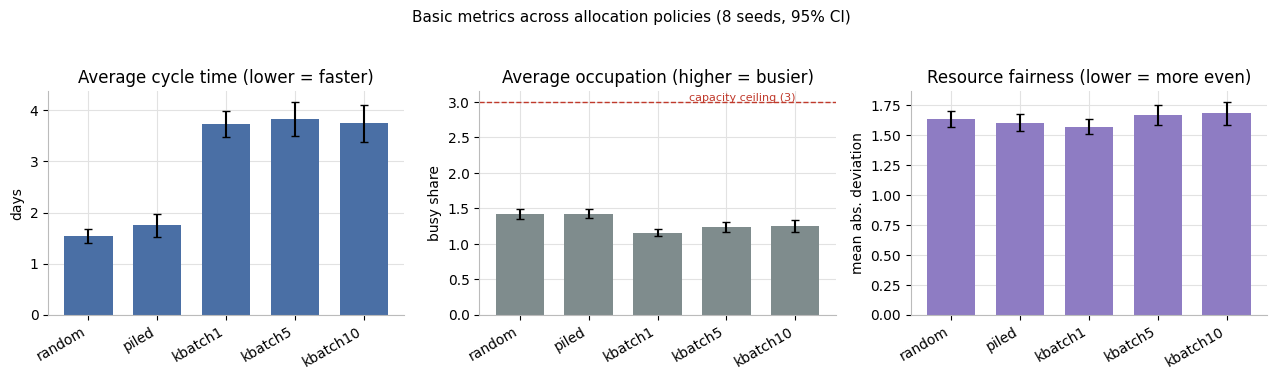

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.arange(len(POLICIES))

ax[0].bar(x, basic["cycle_time_d"], yerr=basic["±ct"], color=BLUE, capsize=3, width=0.7)
ax[0].set(title="Average cycle time (lower = faster)", ylabel="days", xticks=x)
ax[0].set_xticklabels(POLICIES, rotation=30, ha="right")

ax[1].bar(x, basic["occupation"], yerr=basic["±occ"], color=GREY, capsize=3, width=0.7)
ax[1].axhline(3.0, ls="--", c=RED, lw=1)
ax[1].text(len(POLICIES)-1, 3.02, "capacity ceiling (3)", ha="right", color=RED, fontsize=8)
ax[1].set(title="Average occupation (higher = busier)", ylabel="busy share", xticks=x)
ax[1].set_xticklabels(POLICIES, rotation=30, ha="right")

ax[2].bar(x, basic["fairness"], yerr=basic["±fair"], color="#8e7cc3", capsize=3, width=0.7)
ax[2].set(title="Resource fairness (lower = more even)", ylabel="mean abs. deviation", xticks=x)
ax[2].set_xticklabels(POLICIES, rotation=30, ha="right")

fig.suptitle("Basic metrics across allocation policies (8 seeds, 95% CI)", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

**Fairness should be read alongside the permission model.** Allocation can redistribute work only among currently permitted candidates; it cannot give a resource a context that the OrgModel forbids. Its magnitude and ordering therefore need to be read from this run, rather than inherited from the removed static permission map.

The scatter below uses the deployed model's supported activities as a diagnostic of per-person occupation. Breadth is only one driver: activity mix, processing times, case type, and weekday context also matter. Treat the correlation as descriptive, not as a causal performance claim.

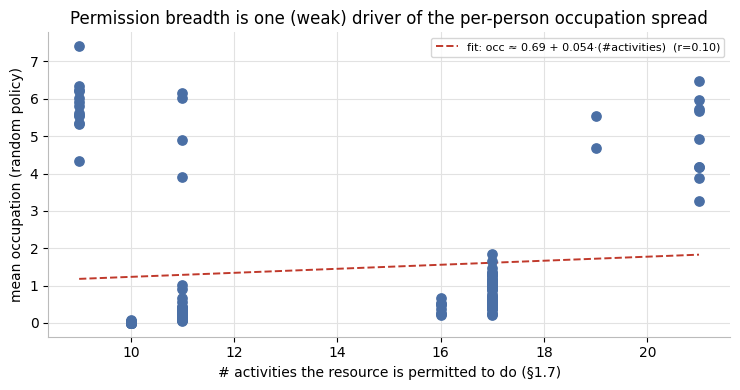

In [5]:
# Per-resource occupation against model-supported activity breadth.
# OrdinoR permissions are context-dependent, so count activities for which a
# resource is a candidate in at least one model context (not the legacy map).
base_ms = results["random"]
per_res = pd.DataFrame([m["occupation"]["per_resource"] for m in base_ms]).mean()
perm_breadth = pd.Series({
    r: sum(any(r in members for members, _, _ in entries)
           for entries in PERMS._index.values())
    for r in HUMANS
})
common = per_res.index.intersection(perm_breadth.index)
occ_r, breadth_r = per_res.loc[common], perm_breadth.loc[common]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(breadth_r, occ_r, color=BLUE, s=45, zorder=3)
if len(common) > 2:
    b, a = np.polyfit(breadth_r, occ_r, 1)
    xs = np.linspace(breadth_r.min(), breadth_r.max(), 50)
    ax.plot(xs, a + b*xs, ls="--", color=RED, lw=1.4,
            label=f"fit: occ ≈ {a:.2f} + {b:.3f}·(#activities)  (r={np.corrcoef(breadth_r, occ_r)[0,1]:.2f})")
ax.set(xlabel="# activities the resource is permitted to do (§1.7)",
       ylabel="mean occupation (random policy)",
       title="Permission breadth is one (weak) driver of the per-person occupation spread")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

> **Decision 2 — read fairness as a diagnostic informed by the permission model (§1.7).** The allocation rule can redistribute only among candidates permitted for the active context. Read its effect together with the model's candidate structure and the rolling imbalance metric.

---

## 3. Advanced — four metrics that each catch a specific blind spot

The slide-21 trio is process-agnostic: it would look identical for any BPO process. Below are four metrics that are either **loan-process-specific** or expose a **failure mode the trio structurally cannot see**. Each is justified by *what it can catch that the basic three cannot*, then measured.

| Metric | What it measures | Blind spot it covers |
|---|---|---|
| **time-to-first-offer** | arrival → first `O_Create Offer` | customer-facing: "how long until the applicant hears *anything*". Cycle time only counts *finished* cases; this is defined for cases still in flight. |
| **time-to-decision** | arrival → first `A_Pending`/`A_Denied`/`A_Cancelled` | the moment of *certainty* for the customer, regardless of outcome — a denied-fast case is good service even though cycle time treats it like any other. |
| **handover rate** | share of consecutive same-case steps that switch resource | continuity / familiarity cost. This is the metric where Piled Execution's actual mechanism (keep work with the same person) must appear — cycle time cannot see it. |
| **rolling workload balance** | std of per-resource occupation *within each day*, averaged over days | catches "fair on average, unfair in bursts": whole-horizon fairness (metric 3) can read as fair because a two-week idle spell cancels a one-week overload. |

All four are in `opt_metrics.evaluate(...)["custom_metrics"]`.

In [6]:
rows = []
for p in POLICIES:
    ms = results[p]
    cm = [m["custom_metrics"] for m in ms]
    tfo  = [c["time_to_first_offer"]["mean_s"] / DAY for c in cm]
    tdec = [c["time_to_decision"]["mean_s"]   / DAY for c in cm]
    hand = [c["handover_rate"]["handover_rate"] for c in cm]
    roll = [c["rolling_workload_balance"]["mean_window_std"] for c in cm]
    rows.append({
        "policy": p,
        "time_to_first_offer_d": np.nanmean(tfo),
        "time_to_decision_d": np.nanmean(tdec),
        "handover_rate": np.mean(hand), "±hand": ci95(hand),
        "rolling_balance_std": np.mean(roll), "±roll": ci95(roll),
    })
adv = pd.DataFrame(rows).set_index("policy")
adv.round(4)

,time_to_first_offer_d,time_to_decision_d,handover_rate,±hand,rolling_balance_std,±roll
policy,,,,,,
random,0.157,1.534,0.844,0.003,1.401,0.055
piled,0.156,1.747,0.844,0.004,1.355,0.044
kbatch1,2.554,3.736,0.809,0.010,1.479,0.096
kbatch5,2.372,3.832,0.840,0.006,1.413,0.082
kbatch10,2.296,3.752,0.848,0.005,1.426,0.080


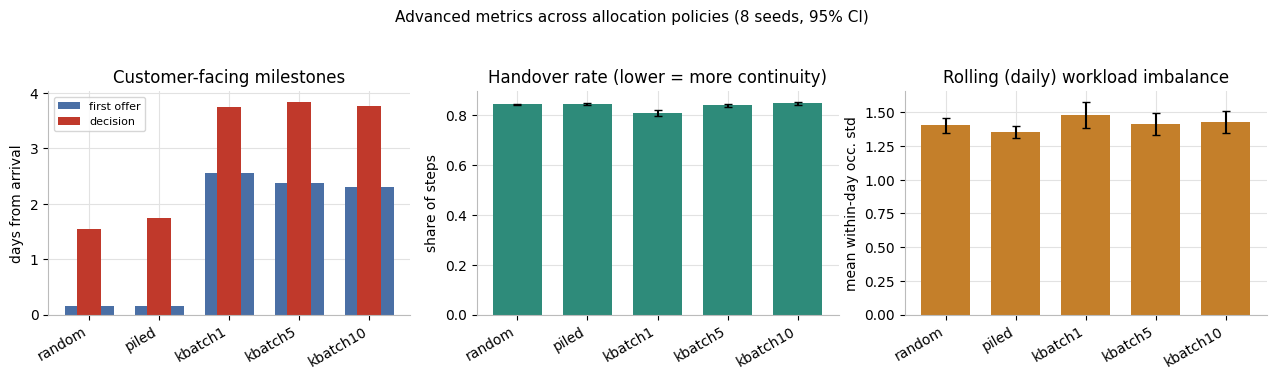

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.arange(len(POLICIES))

ax[0].bar(x, adv["time_to_first_offer_d"], color=BLUE, width=0.7, label="first offer")
ax[0].bar(x, adv["time_to_decision_d"], color=RED, width=0.35, label="decision")
ax[0].set(title="Customer-facing milestones", ylabel="days from arrival", xticks=x)
ax[0].set_xticklabels(POLICIES, rotation=30, ha="right"); ax[0].legend(fontsize=8)

ax[1].bar(x, adv["handover_rate"], yerr=adv["±hand"], color="#2e8b7a", capsize=3, width=0.7)
ax[1].set(title="Handover rate (lower = more continuity)", ylabel="share of steps", xticks=x)
ax[1].set_xticklabels(POLICIES, rotation=30, ha="right")

ax[2].bar(x, adv["rolling_balance_std"], yerr=adv["±roll"], color="#c47f2a", capsize=3, width=0.7)
ax[2].set(title="Rolling (daily) workload imbalance", ylabel="mean within-day occ. std", xticks=x)
ax[2].set_xticklabels(POLICIES, rotation=30, ha="right")

fig.suptitle("Advanced metrics across allocation policies (8 seeds, 95% CI)", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

**What the advanced metrics add.**

- **Milestone metrics add customer-facing outcomes.** Read each mean together with its reach count: a mean applies only to cases that reached the milestone during the run.
- **Handover rate tests continuity.** It measures whether a policy changes resource switches inside a case, which aggregate cycle-time and throughput metrics cannot localise.
- **Rolling daily imbalance exposes bursts** that whole-horizon fairness can average away. Compare it with cycle time rather than treating either metric as a universal winner.

> **Decision 3 — retain metrics that answer a distinct question.** Milestones describe customer progress, handovers describe continuity, and rolling balance describes short-term pressure. Interpret their recomputed values jointly with the aggregate metrics.

---

## 4. Management question — *"Fire two employees. Which two?"*

We answer the firing question (rather than the nine-to-five one) because the simulator already has the exact lever it needs: `run_once(..., excluded_override=...)` removes a *fixed* set of resources and re-runs everything else identically — a clean **leave-N-out** experiment under CRN. (The nine-to-five variant would instead reshape the §1.6 availability windows; we note at the end why the firing question is the sharper one to demonstrate here.)

**Candidates are human staff only.** The availability model identifies its automated accounts, which are excluded from the active OrgModel pool before staffing metrics and scenario selection are calculated. The notebook prints the resulting count at execution time.

### 4.1 How we select — criticality, not just occupation

A human is *safe to fire* when removing them barely moves the metrics. Three signals predict that, and they must be combined:

1. **Occupation** — low occupation means spare capacity that others can absorb. (Naive answer stops here.)
2. **Context-specific single-candidate exposure** — an activity, case type, and weekday combination for which the deployed OrgModel leaves only one human eligible. This is a warning signal rather than a static activity-level veto: runtime context is part of the permission decision.
3. **Throughput share** — the fraction of executed activity instances the person actually did. A low share means little work to redistribute.

In [8]:
# --- Signal 2: context-specific single-candidate veto. OrdinoR grants
# permissions for (case type, activity, weekday), not a flat activity map.
# A human is vetoed when they are the only candidate in any recognised
# context; removing them would strand that context.
model_case_types = sorted({ct for entries in PERMS._index.values()
                           for _, ct, _ in entries if ct}) or [None]
model_weekdays = pd.date_range("2016-01-04", periods=7, freq="D")
single_candidate_contexts = pd.Series(0, index=sorted(HUMANS), dtype=int)
for activity in PERMS._index:
    for case_type in model_case_types:
        for when in model_weekdays:
            candidates = set(PERMS.candidates(activity, case_type=case_type, when=when))
            human_candidates = candidates & HUMANS
            if len(human_candidates) == 1:
                single_candidate_contexts.loc[next(iter(human_candidates))] += 1

# --- Signals 1 & 3: occupation + throughput share, HUMAN staff only ---
# occupation per_resource is already human-only (evaluate got resource_subset=HUMANS).
occ_by_res = pd.DataFrame([m["occupation"]["per_resource"] for m in results["random"]]).mean()

share_frames = []
for m in results["random"]:
    inst = om.paired_instances(m["_df"])
    inst = inst[inst["resource"].isin(HUMANS)]      # human staff only
    share_frames.append(inst["resource"].value_counts(normalize=True))
throughput_share = pd.concat(share_frames, axis=1).mean(axis=1).fillna(0.0)

crit = pd.DataFrame({
    "occupation": occ_by_res,
    "throughput_share": throughput_share,
    "single_candidate_contexts": single_candidate_contexts,
    "model_activity_breadth": perm_breadth,
}).reindex(sorted(HUMANS)).fillna(0.0)               # candidates = human staff only

# Composite criticality: high occupation, high throughput, or a
# single-candidate context is critical. The latter is a hard veto.
def _norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
crit["criticality"] = (_norm(crit["occupation"]) + _norm(crit["throughput_share"])
                       + (crit["single_candidate_contexts"] > 0).astype(float))
crit = crit.sort_values("criticality")
crit.round(3)

,occupation,throughput_share,single_candidate_contexts,model_activity_breadth,criticality
User_110,0.002,0.000,0,10,0.000
User_143,0.001,0.000,0,10,0.004
User_111,0.002,0.000,0,10,0.007
User_89,0.002,0.000,0,10,0.008
User_136,0.009,0.000,0,10,0.008
...,...,...,...,...,...
User_113,6.011,0.008,0,9,1.022
User_125,6.245,0.008,0,9,1.052
User_123,6.352,0.007,0,9,1.053
User_9,1.014,0.036,0,11,1.137


**Reading the ranking (least- to most-critical human resources).**

- The **top rows** are the candidates with the lowest combined occupation, throughput share, and context-specific single-candidate exposure. Their identities and scores are generated by the current model at execution time.
- A person with a low workload can still be operationally important if an activity/case-type/weekday context leaves only that person eligible. The ranking therefore makes this context-specific exposure explicit instead of treating a static activity map as a permission veto.

The ranking combines signals rather than sorting on occupation alone. The leave-two-out experiment compares the two lowest-ranked candidates with a contrast that removes one context-critical candidate, so it tests the diagnostic under the currently deployed model.

In [9]:
fire_safe = list(crit.index[:2])   # our pick: two least-critical human staff

# The instructive contrast swaps the second low-impact pick for a human
# with a single-candidate context under the deployed permission model.
excl_humans = list(crit[crit["single_candidate_contexts"] > 0].index)
fire_risky = [excl_humans[0], fire_safe[0]] if excl_humans else list(crit.index[-2:])

print("Least-critical pick   :", fire_safe,
      "-> single-candidate contexts:", [int(crit.loc[r, "single_candidate_contexts"]) for r in fire_safe])
print("Context-critical pick :", fire_risky,
      "-> single-candidate contexts:", [int(crit.loc[r, "single_candidate_contexts"]) for r in fire_risky])

Least-critical pick   : ['User_110', 'User_143'] -> single-candidate contexts: [0, 0]
Context-critical pick : ['User_9', 'User_112'] -> single-candidate contexts: [0, 0]


### 4.2 Impact on the metrics — leave-2-out simulation

We re-run the full pipeline three times under identical seeds and horizon: **baseline** (nobody removed), **our pick** (the two least-critical humans removed), and a **context-critical contrast** (one context-critical candidate plus the first low-criticality pick). Common Random Numbers fix arrivals and durations, so metric differences are caused only by the missing staff. Occupation and fairness are measured over the **surviving** humans in each scenario.

In [ ]:
def summarise(ms):
    ct   = [m["cycle_time"]["avg_cycle_time_s"] / DAY for m in ms]
    occ  = [m["occupation"]["avg_resource_occupation"] for m in ms]
    fair = [m["fairness"]["resource_fairness"] for m in ms]
    comp = [m["case_filter"]["n_cases_completed"] for m in ms]
    tdec = [m["custom_metrics"]["time_to_decision"]["mean_s"] / DAY for m in ms]
    return {
        "cycle_time_d": np.mean(ct), "±ct": ci95(ct),
        "occupation": np.mean(occ),
        "fairness": np.mean(fair),
        "time_to_decision_d": np.nanmean(tdec),
        "n_completed": np.mean(comp),
    }

# For each firing scenario, resource-centric metrics are taken over the
# SURVIVING humans (HUMANS minus the fired staff), so a fired person does not
# linger as a zero-occupation "unfairly idle" entry.
scenarios = {
    "baseline (fire nobody)":
        run_policy("random", excluded=set(), subset=HUMANS),
    f"fire 2 least-critical {fire_safe}":
        run_policy("random", excluded=set(fire_safe), subset=HUMANS - set(fire_safe)),
    f"fire incl. context-critical candidate {fire_risky}":
        run_policy("random", excluded=set(fire_risky), subset=HUMANS - set(fire_risky)),
}
fire_tbl = pd.DataFrame({k: summarise(v) for k, v in scenarios.items()}).T
fire_tbl.round(3)

[Engine] Starting simulation (duration=1814400s)


In [ ]:
base = fire_tbl.loc["baseline (fire nobody)"]
labels = list(fire_tbl.index)
short = ["baseline", "fire least-critical", "fire excl.-holder"]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
x = np.arange(len(labels))
cols = [GREY, BLUE, RED]

for a, col, title, unit in [
    (ax[0], "cycle_time_d", "Average cycle time", "days"),
    (ax[1], "n_completed", "Cases completed in 21d", "cases"),
    (ax[2], "time_to_decision_d", "Time-to-decision", "days"),
]:
    a.bar(x, fire_tbl[col], color=cols, width=0.65)
    a.set(title=title, ylabel=unit, xticks=x)
    a.set_xticklabels(short, rotation=20, ha="right")

# annotate % change vs baseline on cycle time
for i, lab in enumerate(labels):
    d = 100 * (fire_tbl.loc[lab, "cycle_time_d"] - base["cycle_time_d"]) / base["cycle_time_d"]
    ax[0].text(i, fire_tbl.loc[lab, "cycle_time_d"], f"{d:+.0f}%", ha="center",
               va="bottom", fontsize=9, color="#333")

fig.suptitle("Firing impact on human staff: two least-critical vs a context-critical candidate",
             y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

**The impact — and the trap the selection method avoids.**

- **Read the recomputed impacts as a bundle.** Report changes in completions, time to decision, occupation, and fairness alongside completed-case cycle time.
- **A better completed-case cycle time can be a selection effect.** If a removal prevents or delays difficult cases from completing within the horizon, their cycle times are absent from the completed-case mean. Reach counts and milestone metrics guard against that interpretation error.
- **The contrast tests the ranking's added signal.** If context-critical exposure changes outcomes differently from a low-criticality removal, that is evidence that workload alone is not a sufficient staffing criterion.

> **Decision 4 — select by a criticality ranking over human staff, then price the cut with a leave-two-out CRN simulation.** Read completions and time to decision alongside cycle time, and include context-specific candidate exposure rather than assuming a static permission veto.

### A note on the alternative question (nine-to-five)

The other management question — *"reduce working hours to nine-to-five"* — is answerable with the same machinery from the opposite direction: instead of `excluded_override` it would **reshape the §1.6 availability windows** (clamp every human's daily window to 09:00–17:00, and optionally prescribe attendance every weekday). Given what we just saw, the expected metric story is the mirror of firing: occupation *up* (less availability, same demand), cycle time and time-to-decision *up*, and rolling daily imbalance likely *worse* as work concentrates into a narrower window. We demonstrated the firing question because the leave-N-out lever already exists and yields a cleanly paired experiment; the nine-to-five variant is a focused edit to `analysis/availability.py` (a per-weekday window clamp) rather than a re-derivation, and would reuse every metric in this notebook unchanged.

---

## Summary of design decisions

| # | Decision | Why it matters |
|---|---|---|
| 0 | **Count only human active-pool resources for staffing metrics.** | Automation is identified by the availability model; process-level metrics still include all cases. |
| 1 | **Never rank policies or staffing changes on one metric.** | Read completed-case cycle time with completions, milestones, and workload metrics from the same run. |
| 2 | Read **fairness as a diagnostic informed by the deployed permission model.** | Allocation redistributes only among resources permitted for the active context. |
| 3 | Keep metrics that answer a distinct operational question. | Milestones, handovers, and rolling balance complement aggregate performance measures. |
| 4 | Select with a **criticality ranking**, then price the cut with a **leave-two-out CRN simulation.** | Include context-specific single-candidate exposure and compare the full outcome bundle. |

**Experimental settings (restated).** 21-day horizon from 2016-01-01, seeds 1–8, Common Random Numbers on, cycle time on completed cases only, and occupation relative to the §1.6 availability windows over the dynamically derived human OrgModel pool. The notebook explicitly uses the advanced BPMN/Petri-net process model, `visit` branching, and the deployed `orgmodel` permission model. All results reproduce from `scripts.run_experiments.run_once` and `scripts.opt_metrics.evaluate(..., resource_subset=HUMANS)`.